In [1]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import gc
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import TimeSeriesSplit # cross-val

import itertools
from tqdm import tqdm # loading bar on loops

import warnings
warnings.filterwarnings('ignore')

In [2]:
all_training_df = pd.read_csv("Cleaned Data/all_daily_training_data.csv")
forecast_pred = pd.read_csv("Cleaned Data/forecast_predictors.csv") # Already uses same Sample Sumbission consumer devices
ss = pd.read_csv("SampleSubmission.csv")

climate_daily_df = pd.read_csv("Cleaned Data/climate_daily.csv")


In [3]:
# Ensure the 'Date' column is in datetime format
all_training_df['Date'] = pd.to_datetime(all_training_df['Date'])
forecast_pred['Date'] = pd.to_datetime(forecast_pred['Date'])

climate_daily_df['Date'] = pd.to_datetime(climate_daily_df['Date'])

In [4]:
# Only train and test on the devices in the final submission

# Extract unique consumer devices using regex
temp = ss

# temp[['Date', 'consumer_device_num', 'data_user_num']] = temp['ID'].str.extract(
#     r'^(\d{4}-\d{2}-\d{2})_consumer_device_(\d+)_data_user_(\d+)$'
# )
# sub_devices = temp['consumer_device_num'].unique().astype(int)

temp['Source'] = temp['ID'].str.extract(
    r'(consumer_device_\d+_data_user_\d+)$'
)
sub_sources = temp['Source'].unique()
filter_sub = all_training_df[all_training_df['Source'].isin(sub_sources)]



# Filter rows where the 'Date' is after 2024-07-01
filtered_df = filter_sub[filter_sub['Date'] > pd.Timestamp('2024-07-01')]
filtered_df.head()

,ID,kwh,Date,Source,v_label,consumer_device,data_user,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),...,Total Precipitation (mm),Snowfall (mm),Snow Cover (%),year,month,day,day_of_week,week_of_year,quarter,is_weekend
7836,2024-07-02_consumer_device_12_data_user_1,0.0,2024-07-02,consumer_device_12_data_user_1,0,12,1,15.080516,7.864159,0.324458,...,0.002404,0.0,0.006266,2024,7,2,1,27,3,0
7837,2024-07-03_consumer_device_12_data_user_1,0.0,2024-07-03,consumer_device_12_data_user_1,0,12,1,15.770147,9.578964,0.275826,...,0.004334,0.0,0.002116,2024,7,3,2,27,3,0
7838,2024-07-04_consumer_device_12_data_user_1,0.0,2024-07-04,consumer_device_12_data_user_1,0,12,1,15.277408,11.471116,0.441994,...,0.044775,0.0,0.000000,2024,7,4,3,27,3,0
7839,2024-07-05_consumer_device_12_data_user_1,0.0,2024-07-05,consumer_device_12_data_user_1,0,12,1,13.950413,8.368979,0.368354,...,0.024740,0.0,0.000000,2024,7,5,4,27,3,0
7840,2024-07-06_consumer_device_12_data_user_1,0.0,2024-07-06,consumer_device_12_data_user_1,0,12,1,11.735399,5.797507,-0.058723,...,0.043156,0.0,0.000000,2024,7,6,5,27,3,1


Build a testing framework

For ARIMAX models, **you must fill missing dates** in your time series data. Here's the synthesis of best practices from the search results:

---

### **Key Requirements for ARIMAX**
1. **Continuous Time Index**:  
   ARIMAX requires a complete, regularly spaced time series. Missing dates break the continuity and prevent proper alignment with exogenous variables.

2. **Exogenous Variable Alignment**:  
   Exogenous predictors must be available for **all time points** in your series. Missing dates will create alignment issues between endogenous and exogenous data.

---

### **How to Handle Missing Dates**
| Scenario | Action |
|----------|--------|
| **Missing dates with gaps** | Insert rows for missing dates and: |
| - Endogenous (`kwh`) | Fill with `0`, forward-fill, or interpolate |
| - Exogenous (climate) | Pull corresponding values from `climate_df` |
| **Sparse exogenous data** | Use `fill` (forward/backward) before modeling |

---


In [5]:
all_training_df[all_training_df['Source'] == 'consumer_device_19_data_user_9']

,ID,kwh,Date,Source,v_label,consumer_device,data_user,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),...,Total Precipitation (mm),Snowfall (mm),Snow Cover (%),year,month,day,day_of_week,week_of_year,quarter,is_weekend
42944,2023-10-20_consumer_device_19_data_user_9,0.000000,2023-10-20,consumer_device_19_data_user_9,2,19,9,-6.332381,-14.880799,0.052595,...,2.746600e-05,0.000004,99.972656,2023,10,20,4,42,4,0
42945,2023-10-21_consumer_device_19_data_user_9,0.024911,2023-10-21,consumer_device_19_data_user_9,2,19,9,-5.295542,-14.281367,0.036325,...,1.050740e-04,0.000079,99.972656,2023,10,21,5,42,4,1
42946,2023-10-22_consumer_device_19_data_user_9,0.077299,2023-10-22,consumer_device_19_data_user_9,2,19,9,-5.677233,-9.573318,0.018759,...,1.060670e-02,0.009474,99.972656,2023,10,22,6,42,4,1
42947,2023-10-23_consumer_device_19_data_user_9,0.135352,2023-10-23,consumer_device_19_data_user_9,2,19,9,-9.826207,-12.420219,0.074128,...,7.245300e-04,0.000643,99.972656,2023,10,23,0,43,4,0
42948,2023-10-24_consumer_device_19_data_user_9,0.084518,2023-10-24,consumer_device_19_data_user_9,2,19,9,-9.932194,-13.155241,0.044252,...,2.566940e-04,0.000170,99.972656,2023,10,24,1,43,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43004,2023-12-19_consumer_device_19_data_user_9,0.171794,2023-12-19,consumer_device_19_data_user_9,2,19,9,-13.275834,-24.190632,0.026338,...,3.970000e-06,0.000001,99.972656,2023,12,19,1,51,4,0
43005,2023-12-20_consumer_device_19_data_user_9,0.198135,2023-12-20,consumer_device_19_data_user_9,2,19,9,-10.408076,-21.017629,0.026219,...,6.816000e-06,0.000000,99.972656,2023,12,20,2,51,4,0
43006,2023-12-21_consumer_device_19_data_user_9,0.165506,2023-12-21,consumer_device_19_data_user_9,2,19,9,-11.356148,-21.942704,0.005675,...,4.260000e-07,0.000000,99.972656,2023,12,21,3,51,4,0
43007,2023-12-22_consumer_device_19_data_user_9,0.103060,2023-12-22,consumer_device_19_data_user_9,2,19,9,-8.338924,-18.271471,0.003817,...,8.741808e-03,0.008701,99.972656,2023,12,22,4,51,4,0


In [6]:
sources_used = filtered_df['Source'].unique()

def fill_missing_dates_with_climate_data(filtered_df, climate_df, list_sources = sources_used):
    """
    Detect missing dates for each source, fill them with 0 for 'kwh', 
    and load corresponding climate data for the missing dates.

    Parameters:
        filtered_df (pd.DataFrame): DataFrame containing 'Source', 'Date', and 'kwh'.
        climate_df (pd.DataFrame): DataFrame containing 'Date' and climate-related columns.

    Returns:
        pd.DataFrame: Updated DataFrame with missing dates filled.
    """
    
    updated_dfs = []
    
    # Entire date range
    filtered_start=filtered_df['Date'].min()
    filtered_end=filtered_df['Date'].max()

    # Iterate over unique sources in the filtered DataFrame
    for source in list_sources:
        # Filter data for the current source
        temp = filtered_df[filtered_df['Source'] == source]
        
        # Detect missing daily dates
        full_date_range = pd.date_range(start=filtered_start, end=filtered_end, freq='D')
        missing_dates = full_date_range.difference(temp['Date'])
        
        # Calculate MEDIAN for this source 
        source_median = temp['kwh'].median()
        
        if len(missing_dates) != 0:
#             print(f"Missing dates detected for source: {source}")
            
            # Create a DataFrame for missing dates
            missing_data = pd.DataFrame({
                'Date': missing_dates,
                'Source': source,
                'kwh': source_median  # Use median instead of 0
            })
            # Construct ID from date and source (matches original format)
            missing_data['ID'] = missing_data.apply(
                lambda row: f"{row['Date'].strftime('%Y-%m-%d')}_{row['Source']}", 
                axis=1
            )
            
            # Merge climate data for the corresponding missing dates
            missing_data = missing_data.merge(climate_df, on='Date', how='left')
            
            # Combine original data with filled data
            temp = pd.concat([temp, missing_data], ignore_index=True)
        
        # Sort by date and reset index
        temp = temp.sort_values(by='Date').reset_index(drop=True)
        
        updated_dfs.append(temp)

    # Combine all sources into a single DataFrame
    final_df = pd.concat(updated_dfs, ignore_index=True)
    
    return final_df

filtered_df_sub = fill_missing_dates_with_climate_data(filtered_df, climate_daily_df, list_sources = sources_used)

In [7]:
forecast_df_sub = fill_missing_dates_with_climate_data(forecast_pred, climate_daily_df, list_sources = sources_used)

In [8]:
col = ['kwh', 'Temperature (°C)', 'Dewpoint Temperature (°C)',
       'U Wind Component (m/s)', 'V Wind Component (m/s)',
       'Total Precipitation (mm)', 'Snowfall (mm)', 'Snow Cover (%)', 'year',
       'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend']
filtered_df_sub[filtered_df_sub['Source'] =='consumer_device_2_data_user_1'][col].corr().head(1)

,kwh,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),V Wind Component (m/s),Total Precipitation (mm),Snowfall (mm),Snow Cover (%),year,month,day,day_of_week,week_of_year,quarter,is_weekend
kwh,1.0,-0.50772,-0.530285,-0.426481,-0.454625,-0.170301,0.174259,0.167253,NaN,0.765598,0.097979,0.021075,0.804386,NaN,0.050291


Most significant columns are 'Snow Cover (%)', 'Temperature (°C)', 'Dewpoint Temperature (°C)', North/South 'V Wind Component (m/s)' followed by the year and month

Columns like 'v_label', 'consumer_device', 'data_user' are constant on the same source and have no correlations

In [9]:
# filtered_df_sub['Date'] = pd.to_datetime(filtered_df_sub['Date'])

# Ensure complete datetime index
date_range = pd.date_range(
    start=filtered_df_sub['Date'].min(),
    end=filtered_df_sub['Date'].max()
)
df = filtered_df_sub.set_index('Date')
# Sort the dataframe by date
df = df.sort_index()

# Calculate the split point 
# Create validation date range to be 30 days before the last date
split_date = df.index[-1] - pd.Timedelta(days=30) # index is inclusive exclusive

# Split the data
train_df = df.loc[:split_date].reset_index()
val_df = df.loc[split_date + pd.Timedelta(days=1):].reset_index()

test_df = forecast_pred

def calculate_rmse(actual, predicted):
    """
    Calculate the Root Mean Square Error (RMSE) between actual and predicted values.
    
    Parameters:
    actual (pd.Series or np.array): The actual observed values
    predicted (pd.Series or np.array): The predicted values
    
    Returns:
    float: The RMSE value
    """
    # Ensure both inputs are numpy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Calculate the squared differences
    squared_diff = (actual - predicted) ** 2
    
    # Calculate the mean of squared differences
    mean_squared_diff = np.mean(squared_diff)
    
    # Calculate the square root of the mean squared differences
    rmse = np.sqrt(mean_squared_diff)
    
    return rmse

In [10]:
train_df['Date'].max()

Timestamp('2024-08-24 00:00:00')

In [11]:
val_df['Date'].min()

Timestamp('2024-08-25 00:00:00')

In [12]:
val_df.describe()

,Date,kwh,v_label,consumer_device,data_user,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),V Wind Component (m/s),Total Precipitation (mm),Snowfall (mm),Snow Cover (%),year,month,day,day_of_week,week_of_year,quarter,is_weekend
count,5820,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.0,5820.000000,5820.000000,5820.000000,5820.000000,5820.0,5820.000000
mean,2024-09-08 12:00:00,5.208626,0.922680,22.340206,6.798969,10.447459,5.081519,-0.009901,-0.028036,0.039800,0.000012,0.004026,2024.0,8.766667,15.733333,3.000000,36.500000,3.0,0.300000
min,2024-08-25 00:00:00,0.000000,0.000000,2.000000,1.000000,6.844599,1.086294,-0.458007,-0.344863,0.000047,0.000000,0.000000,2024.0,8.000000,1.000000,0.000000,34.000000,3.0,0.000000
25%,2024-09-01 00:00:00,0.110721,0.000000,13.000000,4.000000,9.878887,2.945390,-0.071244,-0.164794,0.009149,0.000000,0.000000,2024.0,9.000000,8.000000,1.000000,35.000000,3.0,0.000000
50%,2024-09-08 12:00:00,0.223021,1.000000,22.000000,7.000000,10.541979,4.740979,0.003885,0.006851,0.021781,0.000000,0.000000,2024.0,9.000000,15.500000,3.000000,36.500000,3.0,0.000000
75%,2024-09-16 00:00:00,4.570964,2.000000,32.000000,10.000000,11.475153,8.015557,0.064328,0.101698,0.056321,0.000000,0.000326,2024.0,9.000000,23.000000,5.000000,38.000000,3.0,1.000000
max,2024-09-23 00:00:00,110.855212,2.000000,37.000000,19.000000,14.080013,9.057457,0.170258,0.271345,0.173941,0.000216,0.045166,2024.0,9.000000,31.000000,6.000000,39.000000,3.0,1.000000
std,NaN,12.094585,0.824443,10.487403,3.802903,1.724110,2.630486,0.120264,0.174064,0.043511,0.000042,0.009876,0.0,0.422989,8.970844,2.081845,1.258414,0.0,0.458297


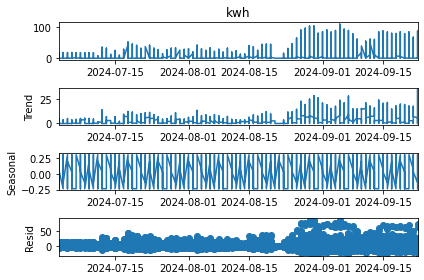

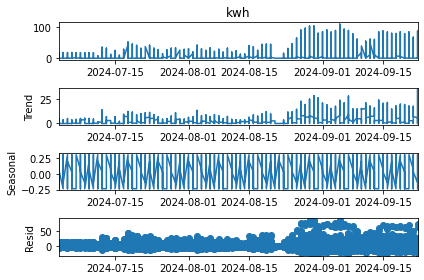

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose time series
result = seasonal_decompose(df['kwh'], model='additive', period=7)  # Adjust period based on known seasonality
result.plot()

try 'order': (7, 1, 2), 'seasonal_order': (1, 0, 1, 7)  # can't have two 7's

(6,1,3)?
order=(7, 1, 0), seasonal_order=(0, 1, 0, 7)


no seasonality
order=(7, 1, 3), seasonal_order=(0, 0, 0, 0)


order= (7, 1, 0), #model.order,

    seasonal_order=(0,1,0,7), #seasonal_order,
    
    
    (0, 0, 1) 	(2, 0, 1, 7) rmse 16.68566325083134 

In [14]:

def forecast_sarimax(input_data, forecast_horizon=30, output_template=None, 
                    order=(7, 1, 0), seasonal_order=(0, 1, 0, 7),
                    exog_cols=None, future_exog_data=None):
    """
    Forecast using SARIMAX model with exogenous variables for each consumer_device/data_user combination
    
    Parameters:
        input_data (DataFrame): Historical data with 'Date', 'Source', and 'kwh'
        forecast_horizon (int): Number of periods to forecast
        output_template (DataFrame): Template for output format
        order (tuple): (p, d, q) non-seasonal order
        seasonal_order (tuple): (P, D, Q, m) seasonal order
        exog_cols (list): List of exogenous variable column names
        future_exog_data (DataFrame): Future exogenous variables with 'Date' and 'Source'
    
    Returns:
        DataFrame: Forecasts with confidence intervals and model metrics
    """
    # Convert Date column to datetime format
    input_data['Date'] = pd.to_datetime(input_data['Date'])
    
    # Extract device/user identifiers
    input_data[['consumer_device', 'data_user']] = (
        input_data['Source'].str.extract(r'consumer_device_(\d+)_data_user_(\d+)')
    )
    
    # Sort data properly
    input_data = input_data.sort_values(by=['consumer_device', 'data_user', 'Date'])
    
    # Prepare output storage
    forecast_results = []

    # Process each device/user combination
    for (consumer_device, data_user), group in input_data.groupby(["consumer_device", "data_user"]):
        try:
            # Filter future exogenous variables for this group
            source_str = f'consumer_device_{consumer_device}_data_user_{data_user}'
            future_group = (future_exog_data[
                future_exog_data['Source'] == source_str
            ].copy() if future_exog_data is not None else None)

            # Prepare time series data
            hist = group.set_index('Date').asfreq('D').sort_index()


            # Handle exogenous variables
            if exog_cols:


                # Forward/backward fill missing exog values
                hist[exog_cols] = hist[exog_cols].ffill().bfill()

                # Prepare future exog
                if future_group is not None:
                    X_future = (future_group.set_index('Date').sort_index()
                                 .asfreq('D')[exog_cols]
                                 .ffill().bfill())
                else:
                    raise ValueError(f"No future exog data for {source_str}")
            
            # Fit SARIMAX model
            model = SARIMAX(
                endog=hist['kwh'],
                exog=hist[exog_cols] if exog_cols else None,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False
            )
            fitted_model = model.fit(disp=False)

            # Generate forecasts
            forecast = fitted_model.get_forecast(
                steps=forecast_horizon,
                exog=X_future[exog_cols] if exog_cols else None
            )
            
            # Create forecast dataframe
            forecast_dates = pd.date_range(
                start=hist.index[-1] + pd.Timedelta(days=1),
                periods=forecast_horizon,
                freq='D'
            )
            
            forecast_df = pd.DataFrame({
                'ID': [f"{d.strftime('%Y-%m-%d')}_consumer_device_{consumer_device}_data_user_{data_user}"
                       for d in forecast_dates],
                'Date': forecast_dates,
                'predicted_kwh': forecast.predicted_mean,
                'ci_lower': forecast.conf_int().iloc[:, 0],
                'ci_upper': forecast.conf_int().iloc[:, 1],
                'aic': fitted_model.aic,
                'bic': fitted_model.bic
            })

            # Merge actuals if available
            if future_group is not None:
                actuals = future_group.set_index('Date')['kwh'].reset_index()
                forecast_df = forecast_df.merge(
                    actuals, 
                    on='Date', 
                    how='left',
                    suffixes=('', '_actual')
                )
            
            forecast_results.append(forecast_df)

        except Exception as e:
            print(f"Error processing {consumer_device}_{data_user}: {str(e)}")
            continue

    # Combine all forecasts
    final_output = pd.concat(forecast_results, ignore_index=True)
    
    # Merge with template if provided
    if output_template is not None:
        output_template = output_template.drop(columns=['kwh'], errors='ignore')
        final_output = output_template.merge(
            final_output,
            on='ID',
            how='left'
        ).fillna(0)
    
    return final_output


Need the seperate climate data as exog predictors because some sources do not have all of the daily climate data

has no data in the validation set

In [15]:
# Prepare exogenous variables
cols_to_use = ['Temperature (°C)', 'Dewpoint Temperature (°C)',
             'U Wind Component (m/s)', 'V Wind Component (m/s)',
             'Total Precipitation (mm)', 'Snowfall (mm)', 
             'Snow Cover (%)']
forecast = forecast_sarimax(input_data=train_df, forecast_horizon=30, output_template=val_df[['ID', 'kwh']], 
                    order=(0, 0, 0), seasonal_order=(1, 1, 1, 7), # Weekly seasonality
                    exog_cols=cols_to_use, future_exog_data=val_df)
rmse = calculate_rmse(forecast['kwh'], forecast['predicted_kwh']) 
# calculate_rmse(val_df['kwh'], forecast['predicted_kwh'])
rmse

15.305284056653731

In [16]:
forecast

,ID,Date,predicted_kwh,ci_lower,ci_upper,aic,bic,kwh
0,2024-08-25_consumer_device_37_data_user_3,2024-08-25,0.995264,0.100914,1.889614,76.008866,92.644482,0.089771
1,2024-08-25_consumer_device_23_data_user_2,2024-08-25,14.232873,-12.609724,41.075470,335.220225,351.855842,24.614358
2,2024-08-25_consumer_device_32_data_user_2,2024-08-25,1.145425,-1.649151,3.940001,160.681257,177.316874,2.801372
3,2024-08-25_consumer_device_22_data_user_4,2024-08-25,1.227929,-6.922033,9.377891,245.477493,262.113110,17.766266
4,2024-08-25_consumer_device_37_data_user_2,2024-08-25,0.747556,0.193769,1.301343,38.851396,55.487013,0.084737
...,...,...,...,...,...,...,...,...
5815,2024-09-23_consumer_device_31_data_user_5,2024-09-23,-0.084113,-1.165780,0.997554,88.340675,104.976292,0.023648
5816,2024-09-23_consumer_device_31_data_user_4,2024-09-23,0.098316,-0.025358,0.221990,-91.618282,-74.982666,0.035089
5817,2024-09-23_consumer_device_31_data_user_3,2024-09-23,0.064019,0.001431,0.126607,-140.336373,-123.700756,0.035554
5818,2024-09-23_consumer_device_32_data_user_11,2024-09-23,0.010306,-0.043335,0.063948,-164.614936,-147.979319,0.135782


In [17]:
from sklearn.feature_selection import mutual_info_regression

# Calculate feature importance
mi_scores = mutual_info_regression(
    df[cols_to_use].fillna(0), 
    df['kwh']
)
mi_df = pd.DataFrame({'feature': cols_to_use, 'mi_score': mi_scores})
keep_cols = mi_df[mi_df.mi_score > 0.05]['feature'].tolist()

# Update exogenous variables
exog_cols = [col for col in cols_to_use if col in keep_cols]
print(f"Selected features: {cols_to_use}")

Selected features: ['Temperature (°C)', 'Dewpoint Temperature (°C)', 'U Wind Component (m/s)', 'V Wind Component (m/s)', 'Total Precipitation (mm)', 'Snowfall (mm)', 'Snow Cover (%)']


In [18]:
df[df['Source'] == 'consumer_device_19_data_user_9']

,ID,kwh,Source,v_label,consumer_device,data_user,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),V Wind Component (m/s),Total Precipitation (mm),Snowfall (mm),Snow Cover (%),year,month,day,day_of_week,week_of_year,quarter,is_weekend
Date,,,,,,,,,,,,,,,,,,,,


 arima model parameters p, d, q in the starter notebook from (5, 1, 0) to (7, 1, 3).  improve rms

The forecast_sarimax function is building a SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) model for each unique combination of consumer_device and data_user, which together make up the "Source" in the dataset. 

The function performs the following key steps:

1. Groups the data by consumer_device and data_user.
2. For each group, it:
   - Prepares the historical data (exog) and future predictors (exog_future).
   - Fits a SARIMAX model using the historical data.
   - Uses the fitted model to forecast power consumption (kwh) for the next month.

3. The forecasts are made using the exog_future data, which contains the predictors for the forecast period.

4. The results are compiled into a forecast dataframe that includes the predicted kwh values for each Source (consumer_device and data_user combination) for the forecast period.

This approach allows for individualized forecasting for each unique power consumption source, taking into account the specific patterns and characteristics of each consumer device and data user combination.

SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) models have several parameters that control different aspects of the time series modeling. Here's an explanation of all the parameters:

## Non-seasonal Components (p, d, q)

1. p (AR order): The number of lag observations in the model. It represents the autoregressive part of the model.
2. d (Differencing degree): The number of times the raw observations are differenced. It helps in making the time series stationary.
3. q (MA order): The size of the moving average window. It represents the moving average part of the model.

## Seasonal Components (P, D, Q, m)

4. P (Seasonal AR order): The number of seasonal lag observations in the model.
5. D (Seasonal differencing degree): The number of seasonal differences required to make the series stationary.
6. Q (Seasonal MA order): The size of the seasonal moving average window.
7. m (Time span of repeating seasonal pattern): The number of periods in each season.

## Exogenous Variables (X)

8. X: External variables that are believed to influence the time series.



The model now includes both ARIMA (7,1,3) and seasonal (1,1,1,7) components assumes weekly seasonality.

The SARIMAX model is fitted with both endogenous (kwh) and exogenous variables.


Forecasting is done using both the fitted model and the future exogenous variables.

This SARIMAX model should provide more accurate forecasts by incorporating seasonal patterns and external factors that influence power generation.

# Finetune 

The seasonal (1,1,1,7) components in a SARIMAX model represent the seasonal part of the time series and can be broken down as follows:

## Seasonal Components (1,1,1,7)

1. Seasonal AR (1): One order of seasonal autoregression
2. Seasonal Differencing (1): One order of seasonal differencing
3. Seasonal MA (1): One order of seasonal moving average
4. Seasonality (7): Weekly seasonality (7 days)

## Tuning Suggestions

1. Adjust seasonality period:
   - If daily data shows monthly patterns, try (1,1,1,30) or (1,1,1,31)
   - For quarterly data, use (1,1,1,4)
   - For monthly data, use (1,1,1,12)

2. Modify seasonal AR and MA orders:
   - Experiment with higher orders, e.g., (2,1,1,7) or (1,1,2,7)
   - Use ACF and PACF plots of seasonally differenced data to guide selection

3. Adjust seasonal differencing:
   - Try (1,0,1,7) if data is already seasonally stationary
   - Use (1,2,1,7) for stronger seasonal trends

4. Grid search:
   - Systematically test combinations of seasonal parameters
   - Use AIC or BIC for model comparison

5. Analyze residuals:
   - Check for remaining seasonality in residuals
   - Adjust components if seasonal patterns persist

6. Consider multiple seasonalities:
   - For complex patterns, explore models like TBATS or Prophet

7. Combine with non-seasonal components:
   - Fine-tune both seasonal and non-seasonal parts together
   - Example: SARIMAX(1,1,1)(1,1,1,7) combines both components



1. v_label: This determines how each building draws power, which is crucial for accurate forecasting. It should definitely be included.

2. Year, month, week, day columns: These provide important temporal information that can help capture long-term trends and seasonality. Including them can improve the model's ability to understand time-based patterns.

3. consumer_device and data_user: These could be encoded as categorical variables to capture device-specific and user-specific patterns.

To incorporate these additional features, we can modify the exog_vars list in the forecast_sarimax function:

```python
exog_vars = ['v_label', 'Temperature (°C)', 'Dewpoint Temperature (°C)', 'U Wind Component (m/s)', 
                         'V Wind Component (m/s)', 'Total Precipitation (mm)', 'Snowfall (mm)', 
                         'Snow Cover (%)','year', 'month', 'day', 'day_of_week', 'week_of_year',
                         'quarter', 'is_weekend']
```

For categorical variables like v_label consumer_device and data_user, we should use one-hot encoding:

```python
# Inside the group loop
group = pd.get_dummies(group, columns=['consumer_device', 'data_user', 'v_label'])
exog = group[exog_vars + [col for col in group.columns if col.startswith(('consumer_device_', 'data_user_', 'v_label_'))]]
```


 conflict between the non-seasonal and seasonal autoregressive components in your SARIMAX model. Specifically, the 7th lag is present in both components, which is not allowed. 

### Final model to use in forcasting

In [19]:
filtered_df_sub['Source'].value_counts()

Source
consumer_device_8_data_user_9     84
consumer_device_12_data_user_1    84
consumer_device_37_data_user_7    84
consumer_device_37_data_user_8    84
consumer_device_37_data_user_9    84
                                  ..
consumer_device_12_data_user_2    84
consumer_device_12_data_user_3    84
consumer_device_12_data_user_4    84
consumer_device_12_data_user_5    84
consumer_device_12_data_user_6    84
Name: count, Length: 194, dtype: int64

In [23]:
forecast = forecast_sarimax(input_data=filtered_df_sub, forecast_horizon=31, output_template=ss, 
                    order=(0, 0, 0), seasonal_order=(1, 1, 1, 7), # Weekly seasonality
                    exog_cols=cols_to_use, future_exog_data=forecast_df_sub)

In [24]:
# prompt: does forecast["kwh"] contain nans if so replace with 0

# Check for NaN values in the 'kwh' column and replace them with 0
forecast["kwh"] = forecast["kwh"].fillna(0)


In [25]:
len(all_training_df), len(forecast), len(ss)

(136409, 6014, 6014)

In [26]:
forecast.to_csv("forecast_SARIMAX_0,0,0_1,1,1,7.csv", index = False)

In [27]:
# prompt: list the difference in the ID between forecast and ss

# Assuming 'forecast' and 'ss' DataFrames are already defined as in your provided code.

# Convert 'ID' columns to sets for efficient comparison
forecast_ids = set(forecast['ID'])
ss_ids = set(ss['ID'])

# Find IDs present in forecast but not in ss
forecast_only_ids = forecast_ids - ss_ids

# Find IDs present in ss but not in forecast
ss_only_ids = ss_ids - forecast_ids

# Print the IDs that are in forecast but not in ss
print("IDs in 'forecast' but not in 'ss':")
print(forecast_only_ids)


# Print the IDs that are in ss but not in forecast
print("\nIDs in 'ss' but not in 'forecast':")
print(ss_only_ids)

# Print the number of IDs that differ
print(f"\nNumber of IDs that differ: {len(forecast_only_ids) + len(ss_only_ids)}")


IDs in 'forecast' but not in 'ss':
set()

IDs in 'ss' but not in 'forecast':
set()

Number of IDs that differ: 0


In [28]:
# prompt: compute RMSE score between forecast and ss

import pandas as pd
from sklearn.metrics import mean_squared_error
import math

# Assuming 'forecast' and 'ss' are DataFrames with a common 'ID' column and a 'kwh' column
# containing the forecast and actual values respectively.

# Merge the forecast and ss DataFrames on the 'ID' column
merged_df = pd.merge(forecast, ss, on='ID', how='left', suffixes=('_forecast', '_actual'))

# Calculate the RMSE
rmse = math.sqrt(mean_squared_error(merged_df['kwh_actual'], merged_df['kwh_forecast']))

print(f"RMSE: {rmse}")


RMSE: 0.0


In [29]:
merged_df

,ID,Source_forecast,Date,predicted_kwh,ci_lower,ci_upper,aic,bic,kwh_forecast,kwh_actual,Source_actual
0,2024-09-24_consumer_device_12_data_user_1,consumer_device_12_data_user_1,2024-09-24,0.139544,-0.009730,0.288818,-129.650601,-107.309536,0,0,consumer_device_12_data_user_1
1,2024-09-25_consumer_device_12_data_user_1,consumer_device_12_data_user_1,2024-09-25,0.121551,-0.027723,0.270826,-129.650601,-107.309536,0,0,consumer_device_12_data_user_1
2,2024-09-26_consumer_device_12_data_user_1,consumer_device_12_data_user_1,2024-09-26,0.213497,0.064223,0.362772,-129.650601,-107.309536,0,0,consumer_device_12_data_user_1
3,2024-09-27_consumer_device_12_data_user_1,consumer_device_12_data_user_1,2024-09-27,0.802884,0.653609,0.952158,-129.650601,-107.309536,0,0,consumer_device_12_data_user_1
4,2024-09-28_consumer_device_12_data_user_1,consumer_device_12_data_user_1,2024-09-28,3.223615,3.074340,3.372889,-129.650601,-107.309536,0,0,consumer_device_12_data_user_1
...,...,...,...,...,...,...,...,...,...,...,...
6009,2024-10-20_consumer_device_8_data_user_9,consumer_device_8_data_user_9,2024-10-20,0.053065,-0.160433,0.266564,-129.691862,-107.350797,0,0,consumer_device_8_data_user_9
6010,2024-10-21_consumer_device_8_data_user_9,consumer_device_8_data_user_9,2024-10-21,0.222991,0.009492,0.436489,-129.691862,-107.350797,0,0,consumer_device_8_data_user_9
6011,2024-10-22_consumer_device_8_data_user_9,consumer_device_8_data_user_9,2024-10-22,0.233432,0.005538,0.461327,-129.691862,-107.350797,0,0,consumer_device_8_data_user_9
6012,2024-10-23_consumer_device_8_data_user_9,consumer_device_8_data_user_9,2024-10-23,5.261475,5.033580,5.489369,-129.691862,-107.350797,0,0,consumer_device_8_data_user_9


SARIMAX
  order=(0, 0, 0), seasonal_order=(1, 1, 1, 7)
  
Train validation RMSE = 15.305284056653731

Submission RMSE = 13.88233814